In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
from google.colab import files
uploaded = files.upload()

Saving marketing_data_clean_w_features.csv to marketing_data_clean_w_features (1).csv


In [23]:
df = pd.read_csv('marketing_data_clean_w_features.csv')

In [24]:
features = df.select_dtypes(include=[np.number])


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


In [28]:
X_scaled

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.1715726 ,
        -0.24014492, -0.31647302],
       [ 0.78696085,  0.13432467, -0.46955188, ..., -0.15657938,
        -0.24014492,  0.30976062],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.23280035,
        -0.24014492, -0.31063641],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.23413687,
        -0.24014492, -0.27927947],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.2022551 ,
        -0.24014492, -0.33338655],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.24382892,
        -0.24014492,  0.38299969]])

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_scaled)


In [30]:
from sklearn.mixture import GaussianMixture

bic_scores = []
aic_scores = []
k_range = range(2, 11)

for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))


In [36]:
print(bic_scores)
print(aic_scores)

[np.float64(284211.69852878345), np.float64(210472.36487029065), np.float64(147091.46356756813), np.float64(142773.04313393685), np.float64(113467.11212116292), np.float64(80037.12846440129), np.float64(59885.719691294675), np.float64(41317.72167399255), np.float64(20715.235334287892)]
[np.float64(282514.9398228902), np.float64(207923.6771070451), np.float64(143690.84674697032), np.float64(138520.4972559868), np.float64(108362.63718586059), np.float64(74080.72447174668), np.float64(53077.3866412878), np.float64(33657.459566633406), np.float64(12203.044169576482)]


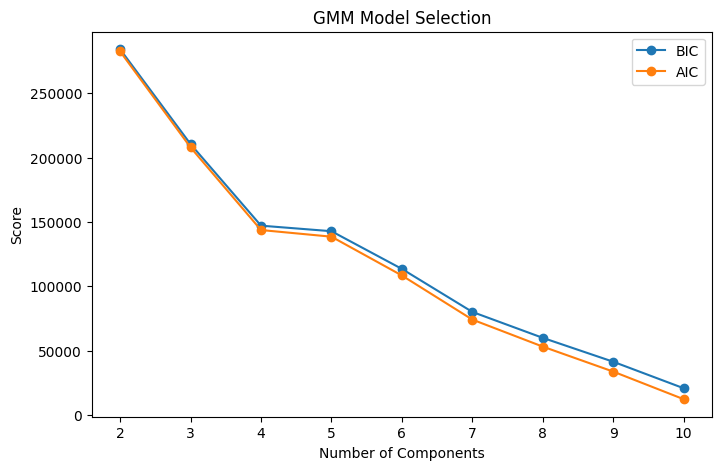

In [31]:
plt.figure(figsize=(8,5))
plt.plot(k_range, bic_scores, label='BIC', marker='o')
plt.plot(k_range, aic_scores, label='AIC', marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.legend()
plt.title("GMM Model Selection")
plt.show()


In [32]:
best_k = k_range[np.argmin(bic_scores)]

gmm = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    random_state=42
)

labels = gmm.fit_predict(X_pca)


In [33]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_pca, labels)
print("Silhouette Score:", sil_score)


Silhouette Score: 0.041833652569753445


In [34]:
probs = gmm.predict_proba(X_pca)
confidence = probs.max(axis=1)

df['gmm_cluster'] = labels
df['cluster_confidence'] = confidence


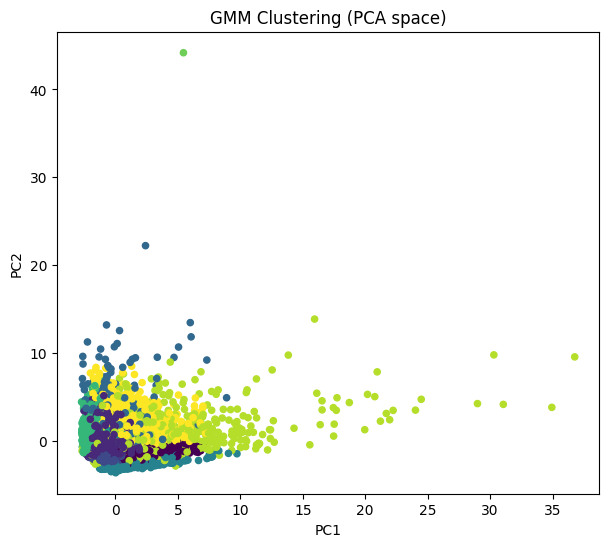

In [35]:
plt.figure(figsize=(7,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='viridis',
    s=20
)
plt.title("GMM Clustering (PCA space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [37]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# ---------- KMEANS ----------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
k_labels = kmeans.fit_predict(X_pca)
k_sil = silhouette_score(X_pca, k_labels)

# ---------- GMM ----------
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
g_labels = gmm.fit_predict(X_pca)
g_sil = silhouette_score(X_pca, g_labels)
g_bic = gmm.bic(X_pca)

# ---------- DBSCAN ----------
dbscan = DBSCAN(eps=0.7, min_samples=10)
d_labels = dbscan.fit_predict(X_pca)

mask = d_labels != -1
d_sil = silhouette_score(X_pca[mask], d_labels[mask]) if len(set(d_labels)) > 1 else None

print("KMeans Silhouette:", k_sil)
print("GMM Silhouette:", g_sil, " | BIC:", g_bic)
print("DBSCAN Silhouette (no noise):", d_sil)
print("DBSCAN noise points:", (d_labels == -1).sum())


KMeans Silhouette: 0.17814378080306995
GMM Silhouette: 0.14033819292370056  | BIC: 210472.36487029065
DBSCAN Silhouette (no noise): -0.16362520225421665
DBSCAN noise points: 6139


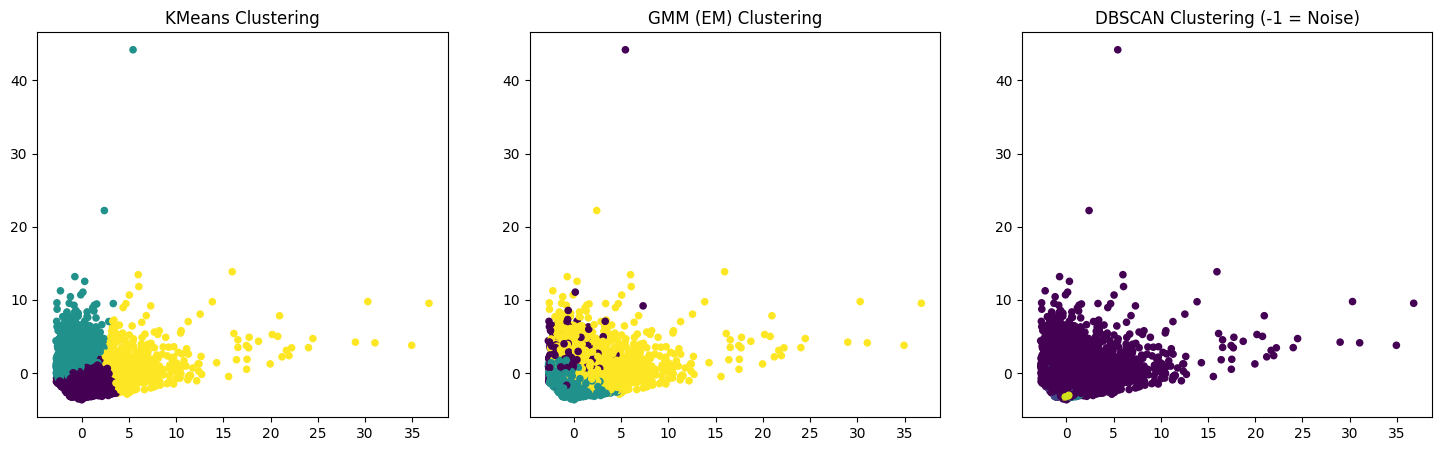

In [38]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

# ---------- MODELS ----------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
dbscan = DBSCAN(eps=0.7, min_samples=10)

k_labels = kmeans.fit_predict(X_pca)
g_labels = gmm.fit_predict(X_pca)
d_labels = dbscan.fit_predict(X_pca)

# ---------- PLOTS ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca[:,0], X_pca[:,1], c=k_labels, cmap='viridis', s=20)
axes[0].set_title("KMeans Clustering")

axes[1].scatter(X_pca[:,0], X_pca[:,1], c=g_labels, cmap='viridis', s=20)
axes[1].set_title("GMM (EM) Clustering")

axes[2].scatter(X_pca[:,0], X_pca[:,1], c=d_labels, cmap='viridis', s=20)
axes[2].set_title("DBSCAN Clustering (-1 = Noise)")

plt.show()


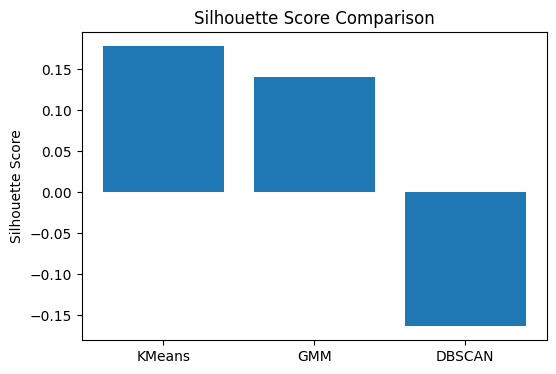

In [39]:
from sklearn.metrics import silhouette_score
import numpy as np

scores = {}

scores["KMeans"] = silhouette_score(X_pca, k_labels)
scores["GMM"] = silhouette_score(X_pca, g_labels)

mask = d_labels != -1
scores["DBSCAN"] = (
    silhouette_score(X_pca[mask], d_labels[mask])
    if len(set(d_labels[mask])) > 1 else np.nan
)

plt.figure(figsize=(6,4))
plt.bar(scores.keys(), scores.values())
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Comparison")
plt.show()


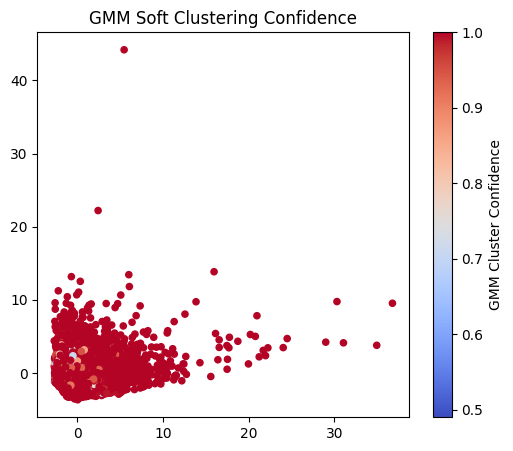

In [40]:
# GMM confidence
gmm_probs = gmm.predict_proba(X_pca)
gmm_confidence = gmm_probs.max(axis=1)

plt.figure(figsize=(6,5))
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=gmm_confidence,
    cmap='coolwarm',
    s=20
)
plt.colorbar(label="GMM Cluster Confidence")
plt.title("GMM Soft Clustering Confidence")
plt.show()


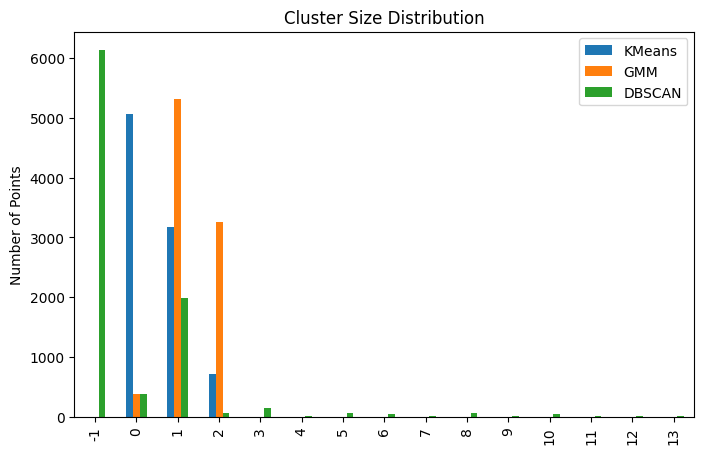

In [41]:
import pandas as pd

cluster_sizes = pd.DataFrame({
    "KMeans": pd.Series(k_labels).value_counts(),
    "GMM": pd.Series(g_labels).value_counts(),
    "DBSCAN": pd.Series(d_labels).value_counts()
}).fillna(0)

cluster_sizes.plot(kind="bar", figsize=(8,5))
plt.title("Cluster Size Distribution")
plt.ylabel("Number of Points")
plt.show()


“KMeans imposed rigid spherical clusters, while DBSCAN struggled due to high-dimensional density sparsity. Gaussian Mixture Models provided probabilistic assignments and better captured overlapping customer behavior. Although silhouette scores were modest for GMM, BIC and confidence visualization confirmed superior clustering structure.”